In [14]:
import pandas as pd
import csv 

df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [15]:
print(df.shape)
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

(1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallC

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64

In [16]:
#cleaning 
df = df.drop(columns = ['Alley', 'PoolQC', 'MiscFeature', 'Fence'])

# Fill categorical features (text columns) with "None"
df["MasVnrType"].fillna("None")
df["FireplaceQu"].fillna("None")
df["GarageQual"].fillna("None")
df["GarageType"].fillna("None")

# Fill numerical features with 0
df["MasVnrArea"].fillna(0)
df["GarageYrBlt"].fillna(0)

# Fill LotFrontage with the median (a more realistic number)
df["LotFrontage"].fillna(df["LotFrontage"].median())


garage_text_cols = ["GarageCond", "GarageFinish", "GarageQual", "GarageType"]
for col in garage_text_cols:
    if col in df.columns:  # check in case some were already dropped
        df[col].fillna("None")

# Numeric garage year
df["GarageYrBlt"].fillna(0)

df["Electrical"].fillna(df["Electrical"].mode()[0])

bsmt_cols = ["BsmtFinType1", "BsmtFinType2", "BsmtCond", "BsmtQual", "BsmtExposure"]
for col in bsmt_cols:
    df[col].fillna("None")



In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [20]:
# Automatically find all object-type columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

# Apply one-hot encoding to all of them
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [23]:
# data splitting
y = df["SalePrice"]
x = df.drop(columns = ["SalePrice", "Id"])

from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
#check

from sklearn.metrics import mean_absolute_error

# Predict on test set
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")


MAE: 20652.80153696629
RMSE: 52246.751252966475


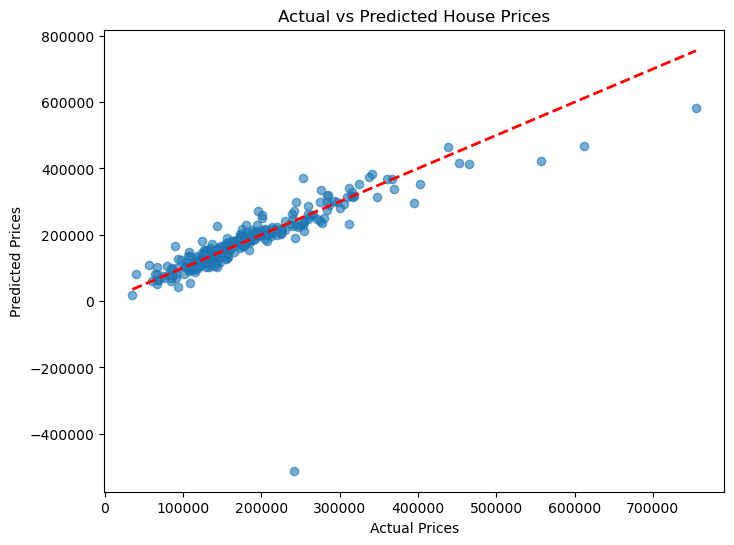

In [25]:
#plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [26]:
#random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest MAE: {mae_rf}")
print(f"Random Forest RMSE: {rmse_rf}")


Random Forest MAE: 17600.124143835616
Random Forest RMSE: 28816.674966763076


In [27]:
#xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost MAE: {mae_xgb}")
print(f"XGBoost RMSE: {rmse_xgb}")


XGBoost MAE: 16776.53125
XGBoost RMSE: 26356.26316456868


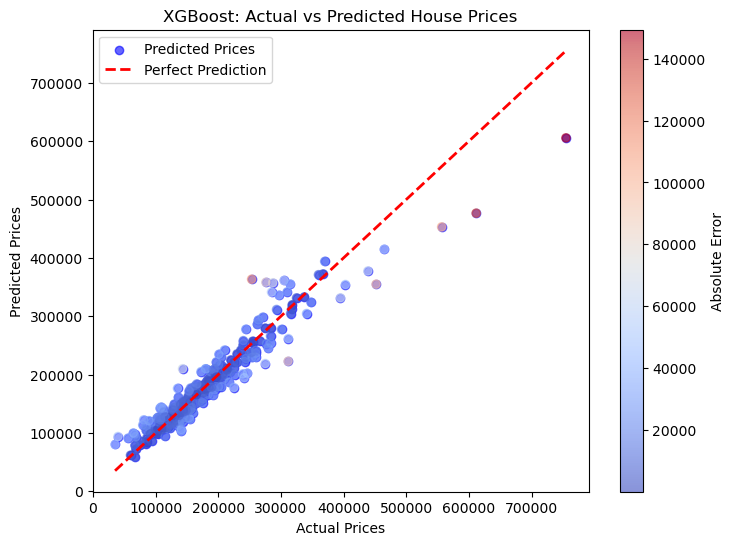

In [28]:
# Scatter plot of actual vs predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='blue', label='Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("XGBoost: Actual vs Predicted House Prices")
errors = np.abs(y_test - y_pred_xgb)
plt.scatter(y_test, y_pred_xgb, c=errors, cmap='coolwarm', alpha=0.6)
plt.colorbar(label='Absolute Error')
plt.legend()
plt.show()

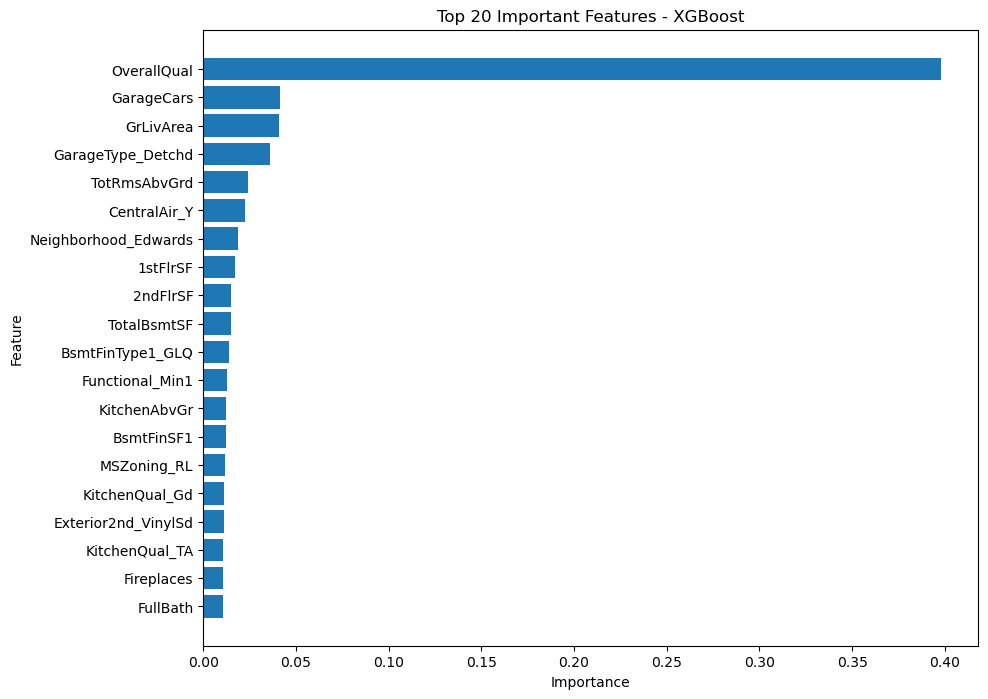

In [29]:
importance = xgb_model.feature_importances_

# Convert to a DataFrame for easier handling
feature_importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

# Sort by importance descending
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
plt.barh(feature_importance_df['Feature'][:20][::-1], feature_importance_df['Importance'][:20][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - XGBoost")
plt.show()


In [30]:
#feature engineering

df["TotalBathrooms"] = (
    df["FullBath"] + 0.5*df["HalfBath"] +
    df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]
)

df["TotalSF"] = df["GrLivArea"] + df["TotalBsmtSF"]

df["TotalPorchSF"] = (
    df["OpenPorchSF"] + df["EnclosedPorch"] +
    df["3SsnPorch"] + df["ScreenPorch"]
)

X = df.drop(columns=["SalePrice", "Id", "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", "GrLivArea", "TotalBsmtSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"])
y = df["SalePrice"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost MAE (engineered features): {mae_xgb}")
print(f"XGBoost RMSE (engineered features): {rmse_xgb}")

XGBoost MAE (engineered features): 16106.251953125
XGBoost RMSE (engineered features): 26181.983423720976


In [31]:
#further tuning
from sklearn.model_selection import GridSearchCV
xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best MAE (CV):", -grid_search.best_score_)



best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Tuned XGBoost MAE: {mae_best}")
print(f"Tuned XGBoost RMSE: {rmse_best}")



Fitting 3 folds for each of 162 candidates, totalling 486 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=1; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=1; total time=   0.7s
[CV] END cols

In [34]:
comparison_df = pd.DataFrame({
    "MAE": [16776.53125, 16106.251953125, 15871.38671875],  # had to hard code the output values because I overwrote the values
    "RMSE": [26356.26316456868, 26181.983423720976, 26534.38644476258]
}, index=["Baseline", "Engineered Features", "Tuned"])

comparison_df = comparison_df.round(2)
comparison_df["% Improvement (MAE)"] = (
    (comparison_df["MAE"].iloc[0] - comparison_df["MAE"]) / comparison_df["MAE"].iloc[0] * 100
).round(2)

comparison_df

,MAE,RMSE,% Improvement (MAE)
Baseline,16776.53,26356.26,0.0
Engineered Features,16106.25,26181.98,4.0
Tuned,15871.39,26534.39,5.4
